In [1]:
"""
Triangle 库网格剖分参数测试
============================
测试不同参数下 Delaunay 三角剖分的效果。

Triangle 参数说明:
  - q<N>: 最小角度约束 (quality mesh), 如 q20 = 最小角 20°
  - a<N>: 最大面积约束, 如 a0.1 = 最大三角形面积 0.1
  - p: 输入为平面直线图 (Planar Straight Line Graph)
  - e: 输出边信息
"""

import numpy as np
import matplotlib.pyplot as plt
from triangle import triangulate

from mesh.mesh2d import GenMesh2D

plt.rcParams.update({'figure.dpi': 100, 'font.size': 9})
print("Import OK")

Import OK


In the whole domain: 
357 points
603 elements
958 faces/edges


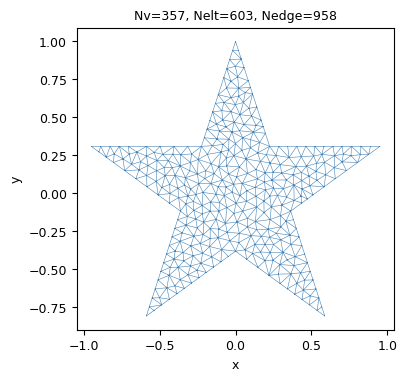

In [2]:
def make_mesh(boundary_type='polygon', param='pq30a0.01e'):
    """快速创建网格并返回 stats"""
    dg = GenMesh2D(boundary_type=boundary_type, param=param, Nint_elt=7, Nint_edge=5)
    return dg

def plot_mesh(dg, ax=None, title=None, show_points=False):
    """绘制单个网格"""
    if ax is None:
        _, ax = plt.subplots(figsize=(4.5, 4))
    points = dg.points
    tri = dg.Mesh_pinx
    ax.triplot(points[:, 0], points[:, 1], tri, linewidth=0.4, color='steelblue')
    if show_points:
        ax.plot(points[:, 0], points[:, 1], 'o', markersize=0.8, color='red')
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    info = f"Nv={dg.Nv}, Nelt={dg.Nelt}, Nedge={dg.Nedge}"
    title_str = f"{title}\n{info}" if title else info
    ax.set_title(title_str, fontsize=9)
    return ax

# 快速测试
dg = make_mesh('polygon', 'pq30a0.003e')
dg.print_grid_info()
plot_mesh(dg)
plt.show()

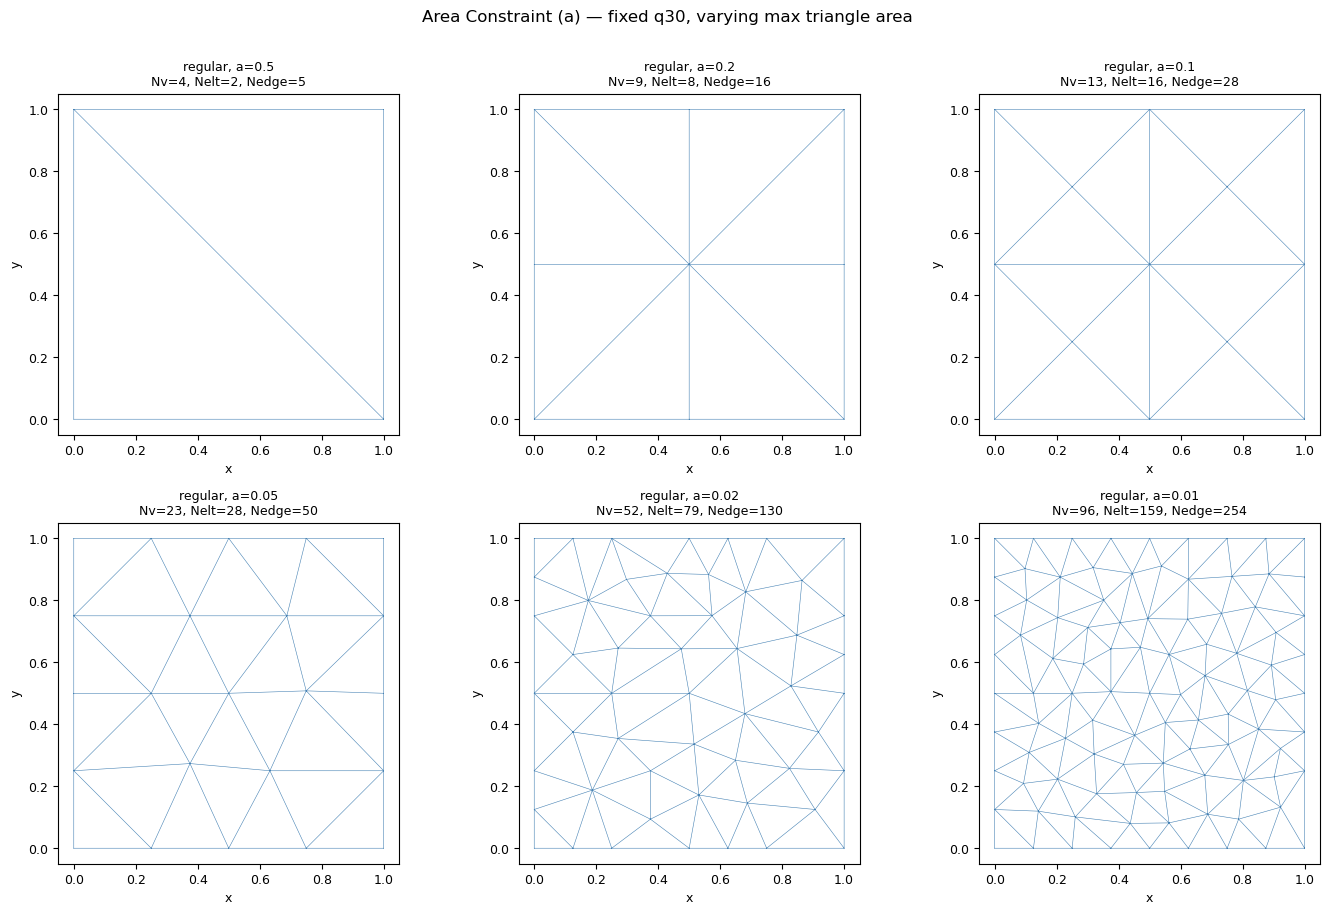

In [8]:
# ============================================================
# 测试 1: 不同最大面积约束 (a 参数)
# 固定 q30 (最小角30°), 改变 a 观察网格密度变化
# ============================================================

area_params = [
    ('pq30a0.5e',  'a=0.5'),
    ('pq30a0.2e',  'a=0.2'),
    ('pq30a0.1e',  'a=0.1'),
    ('pq30a0.05e', 'a=0.05'),
    ('pq30a0.02e', 'a=0.02'),
    ('pq30a0.01e', 'a=0.01'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for (param, label), ax in zip(area_params, axes.flat):
    dg = make_mesh('regular', param)
    plot_mesh(dg, ax=ax, title=f'regular, {label}')

fig.suptitle('Area Constraint (a) — fixed q30, varying max triangle area',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1391000/2560835929.py:22: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1391000/2560835929.py:22: UserWarning: Glyph 35282 (\N{CJK UNIFIED IDEOGRAPH-89D2}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1391000/2560835929.py:22: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1391000/2560835929.py:22: UserWarning: Glyph 32422 (\N{CJK UNIFIED IDEOGRAPH-7EA6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1391000/2560835929.py:22: UserWarning: Glyph 26463 (\N{CJK UNIFIED IDEOGRAPH-675F}) missing from current font.
  plt.tight_layout()
/root/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/root/anaconda3/lib/python3.9/site-packages/IPython/core/pylab

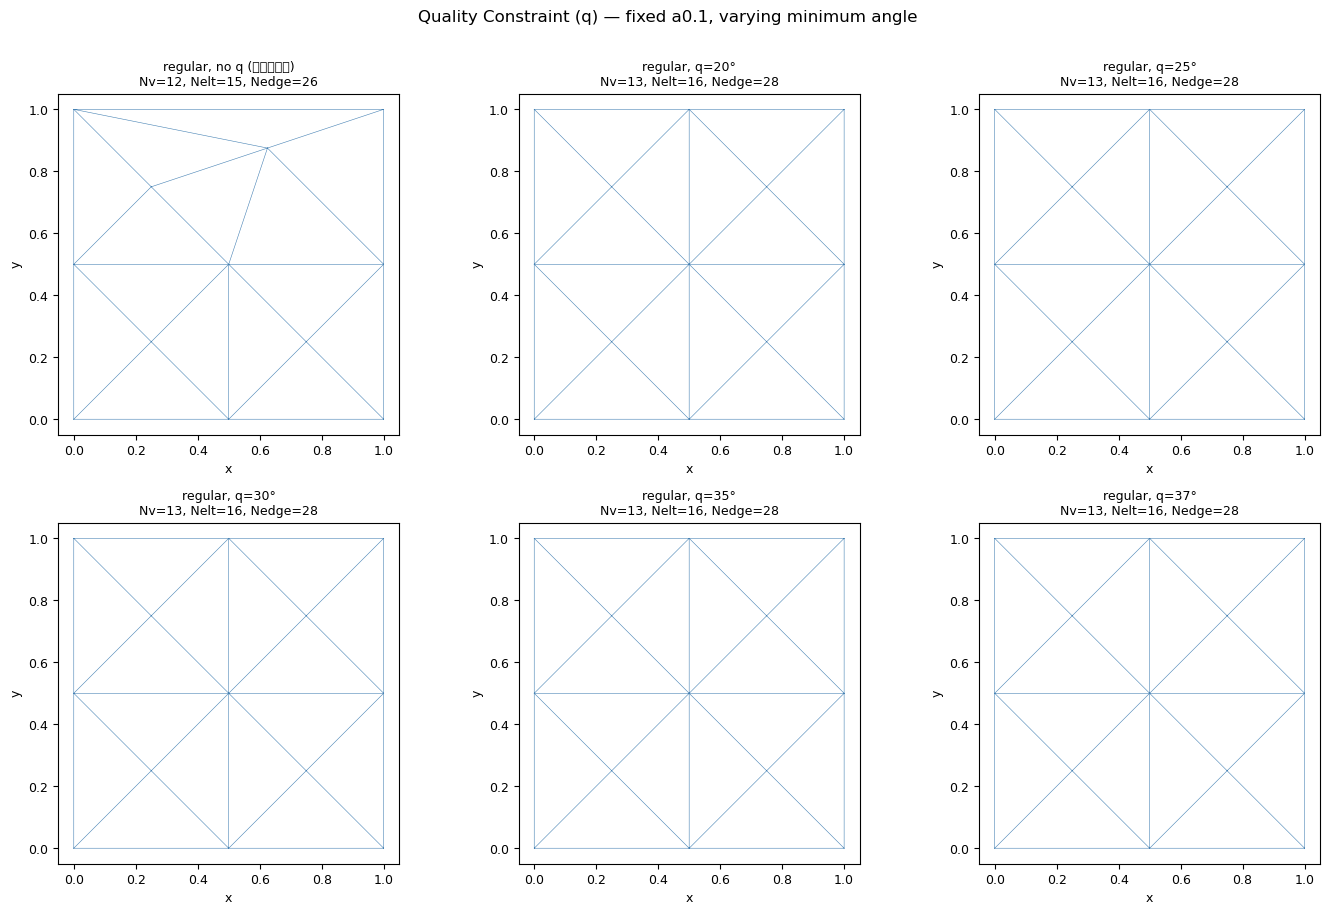

In [9]:
# ============================================================
# 测试 2: 不同最小角度约束 (q 参数)
# 固定 a0.1 (最大面积 0.1), 改变 q 观察网格质量变化
# ============================================================

quality_params = [
    ('pa0.1e',   'no q (无角度约束)'),
    ('pq20a0.1e', 'q=20°'),
    ('pq25a0.1e', 'q=25°'),
    ('pq30a0.1e', 'q=30°'),
    ('pq35a0.1e', 'q=35°'),
    ('pq37a0.1e', 'q=37°'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for (param, label), ax in zip(quality_params, axes.flat):
    dg = make_mesh('regular', param)
    plot_mesh(dg, ax=ax, title=f'regular, {label}')

fig.suptitle('Quality Constraint (q) — fixed a0.1, varying minimum angle',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

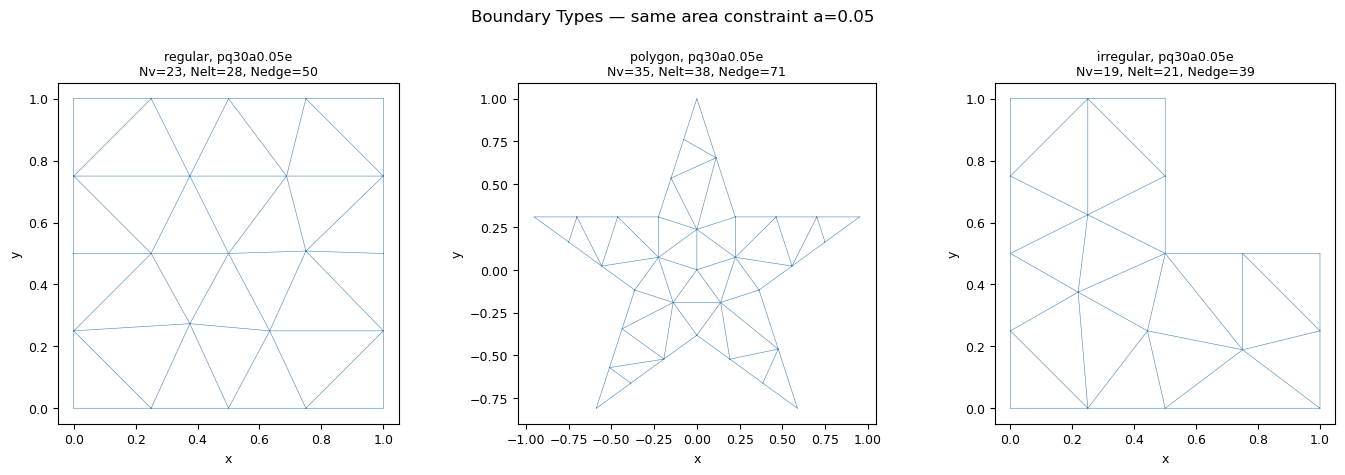

In [10]:
# ============================================================
# 测试 3: 不同边界类型
# 固定 pq30a0.1e, 对比 regular / polygon / irregular 三种区域
# ============================================================

boundary_types = ['regular', 'polygon', 'irregular']
param = 'pq30a0.05e'

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for btype, ax in zip(boundary_types, axes):
    dg = make_mesh(btype, param)
    plot_mesh(dg, ax=ax, title=f'{btype}, {param}')

fig.suptitle('Boundary Types — same area constraint a=0.05',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

       a      Nv    Nelt   Nedge     h_est
---------------------------------------------
   0.500       4       2       5    0.7071
   0.200       9       8      16    0.3536
   0.100      13      16      28    0.2500
   0.050      23      28      50    0.1890
   0.020      52      79     130    0.1125
   0.010      96     159     254    0.0793
   0.005     182     320     501    0.0559


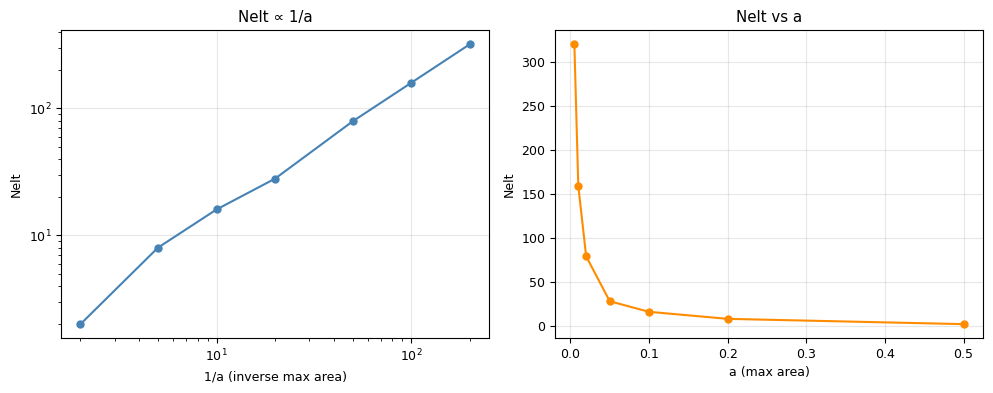

In [11]:
# ============================================================
# 测试 4: 网格规模统计 — h-refinement 参考
# 观察不同 a 参数下 Nelt 的增长规律
# ============================================================

area_list = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005]
stats = []

for a in area_list:
    dg = GenMesh2D(boundary_type='regular', param=f'pq30a{a}e', Nint_elt=7, Nint_edge=5)
    stats.append({
        'a': a,
        'Nv': dg.Nv,
        'Nelt': dg.Nelt,
        'Nedge': dg.Nedge,
        'h_est': 1.0 / np.sqrt(dg.Nelt),  # 等效网格尺寸
    })

# 打印表格
print(f"{'a':>8s}  {'Nv':>6s}  {'Nelt':>6s}  {'Nedge':>6s}  {'h_est':>8s}")
print("-" * 45)
for s in stats:
    print(f"{s['a']:8.3f}  {s['Nv']:6d}  {s['Nelt']:6d}  {s['Nedge']:6d}  {s['h_est']:8.4f}")

# Nelt ~ 1/a 关系图
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

a_vals = np.array([s['a'] for s in stats])
nelt_vals = np.array([s['Nelt'] for s in stats])

axes[0].loglog(1/a_vals, nelt_vals, 'o-', color='steelblue', markersize=5)
axes[0].set_xlabel('1/a (inverse max area)')
axes[0].set_ylabel('Nelt')
axes[0].set_title('Nelt ∝ 1/a')
axes[0].grid(True, alpha=0.3)

axes[1].plot(a_vals, nelt_vals, 'o-', color='darkorange', markersize=5)
axes[1].set_xlabel('a (max area)')
axes[1].set_ylabel('Nelt')
axes[1].set_title('Nelt vs a')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()